## Libraries

In [1]:
import os

In [2]:
run = 'local' #local or cloud
os.environ["APP_ENV"] = run

In [3]:
import sys
sys.path.append('..')

In [4]:
from src.grass_functions import*
from src.process_inputs import*
%matplotlib inline
#%load_ext autoreload
#%autoreload 2

C:\Program Files\GRASS GIS 7.8\etc\python\grass\script\db.py:147: SyntaxWarning: invalid escape sequence '\g'
  :param str args:  see \gmod{db.select} arguments
C:\Program Files\GRASS GIS 7.8\etc\python\grass\script\setup.py:30: SyntaxWarning: invalid escape sequence '\O'
  grass7bin = r'C:\OSGeo4W\bin\grass78.bat'
C:\Program Files\GRASS GIS 7.8\etc\python\grass\pygrass\modules\interface\parameter.py:141: SyntaxWarning: invalid escape sequence '\d'
  isrange = re.match("(?P<min>-*\d+.*\d*)*-(?P<max>\d+.*\d*)*",
C:\Program Files\GRASS GIS 7.8\etc\python\grass\pygrass\modules\interface\module.py:233: SyntaxWarning: invalid escape sequence '\_'
  To run the Module objects in parallel the run\_ and finish\_ options


# Parameters

In [5]:
#set project variables
Project_Area = 'steer'
projection = '102761' #set to None if you want to use the DEM's original projection
res = '1m'

## Set variables analysis
source = 'wbd' #wbd or user-defined
data_scale = 'HUC12' #other options HUC12, HUC10, HUC8 OR the field name of the source data to be split <-- case sensitive
select_data = '210200010103' #     # Value within the filter_field used for data selection
to_headwaters = False #False if only interested in local huc area
input_shp_name = None #None or must be populated populated with a shapefile polygons if data_scale != HUCXX
buffer = 2000
auto_delete = False

In [6]:
if data_scale.find('HUC') >= 0:
    huc_level = re.findall("[0-9]+",data_scale)[0]
    if huc_level == str(len(select_data)):
        huc_digys = huc_level
    else:
        huc_digys = huc_level
        select_data = select_data[:int(huc_digys)]

In [7]:
## Paths:
parent_dir = pl.Path(os.getcwd()).parent/'data'
current_dir = pl.Path(os.getcwd())
outputs_dir =parent_dir/'Rasters'/Project_Area/'Outputs'
vector_dir = parent_dir/'Vectors'/Project_Area
raster_dir = parent_dir/'Rasters'/Project_Area
huc_path = vector_dir/'{}_aoi.geojson'.format(Project_Area)
git_data_repo = current_dir/'data_repository'
if input_shp_name:
    input_shp = vector_dir/input_shp_name
directory = outputs_dir

### Get area of interest

In [8]:
#read from to vector path from notebook 1
huc_path = vector_dir/'{0}_{1}_aoi.geojson'.format(Project_Area,select_data)
aoi = gpd.read_file(str(huc_path),driver="GeoJSON")

c:\Users\Curtis.Smith\AppData\Local\miniforge3\envs\geoenv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


### Start new grass session

In [9]:
# define GRASS data settings (adapt to your needs)
location = Project_Area+'_'+projection
mapset = 'PERMANENT'

In [11]:
initialize_grass_db(location, mapset, projection)
#initialize_grass_db(location, mapset, projection)

{'GISDBASE': "'C:\\Users\\Curtis.Smith\\Documents\\grassdata';", 'LOCATION_NAME': "'steer_102761';", 'MAPSET': "'PERMANENT';"}
Database Mapset Exists
None
{'GISDBASE': 'C:\\Users\\Curtis.Smith\\Documents\\grassdata', 'LOCATION_NAME': 'steer_102761', 'MAPSET': 'PERMANENT'}


#### Review existing files

In [13]:
gs.run_command('g.remove',type='raster',name='None',flags='f')

0

In [14]:
#list all grass files
grass_maps = list_existing_grass(print_it=True)

Available vector maps:

Available raster maps:


In [16]:
basin_list = aoi[data_scale.lower()].to_list()
basins = 'aoi'
gs.parse_command('v.import', input= huc_path,  output= basins)
print('added aoi to grass')

added aoi to grass


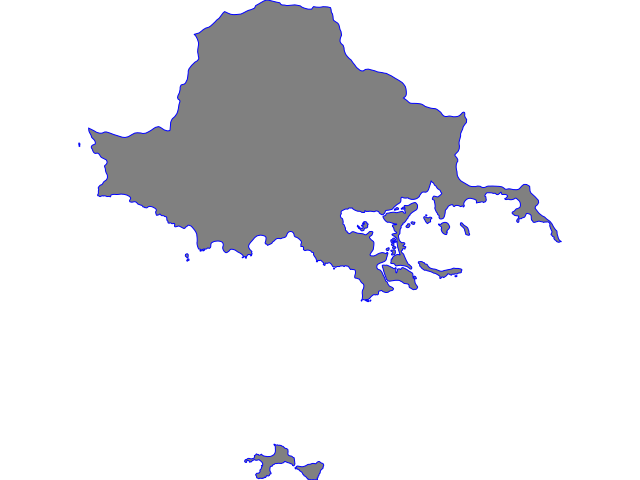

In [17]:
##print basins in grass @ Regional scale to confirm data and extent
gs.parse_command('g.region',vector = basins)
gs.run_command('d.erase')

#gs.run_command('d.vect', map='tmp_bsn_buffer',color='red',fill_color='gray')
gs.run_command('d.vect', map= basins,color='blue',fill_color='gray')

Image(filename="map.png")

### Get Raster data

#### Must first run DEM Download Notebook at
[DEM Download](DEM_download.ipynb#section_id1)
<a id='section_id1'></a>

#### Import raster tiles in correct projection and units

In [18]:
##combine and convert all raster tiles output from DEM Download Notebook into UTM Zone feet vert unit
dems = dem_tiles_to_gis(gs,raster_dir/'dem',Project_Area,'feet',delete_raw=True,force=False) #if patch = True returns joined DEM 

adding raster USGS_1m_x30y204_PR_PRVI_VI_B1_2018_2020_04_29


[2026-04-22 10:52:41,236] [INFO] [grass_functions] : converting vertical units to feet. Raw DEM * 3.280839895013123


In [19]:
b_dems = basin_dems(dems,basins, basin_list,data_scale,raster_dir,buffer = (buffer), remove_tiles = True,fill_nulls = False,export_tiff = True) #can add option to ignore nulls, buffer distance is in map units

Patching together rasters for 210200010103
created dem_210200010103.tif


In [20]:
gs.run_command('v.db.dropcolumn',map= basins, column='MetaSourceID,SourceDataDesc,SourceOriginator,SourceFeatureID,Shape_Length,noncontributingareaacres,noncontributingareasqkm')
gs.run_command('v.db.dropcolumn',map= basins, column='MetaSourceID,SourceDataDesc,SourceOriginator,SourceFeatureID,Shape_Length'.lower())
gs.run_command('v.out.ogr', input=  basins,type = 'area',output = vector_dir/'{}.shp'.format(select_data), format = 'ESRI_Shapefile',flags='e')

CalledModuleError: Module run None v.out.ogr -e input=aoi type=area output=c:\git\dem_prep\data\Vectors\steer\210200010103.shp format=ESRI_Shapefile ended with error
Process ended with non-zero return code 1. See errors in the (error) output.

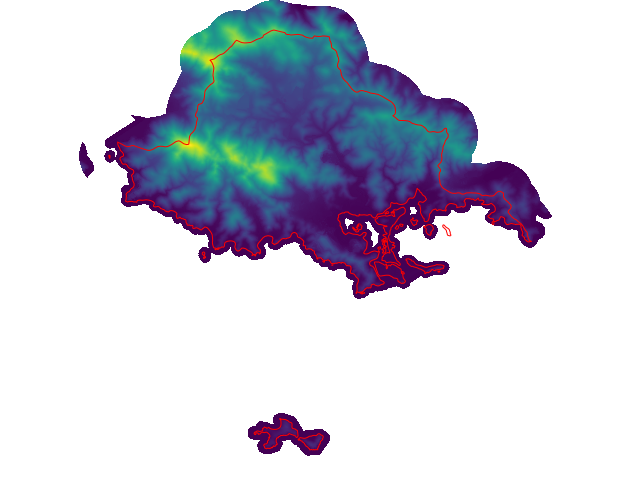

In [21]:
##print basins in grass @ Regional scale to confirm data and extent
gs.parse_command('g.region',vector = 'tmp_bsn_buffer', align = b_dems[0])
gs.run_command('d.erase')
gs.run_command('d.rast', map= b_dems[0])
gs.run_command('d.vect', map= basins,color='red',fill_color='None')
Image(filename="map.png")

In [24]:
#export
gs.run_command('r.out.gdal', input= b_dems[0], output= raster_dir/f'{b_dems[0]}.tif',createopt="BIGTIFF=YES,PROFILE=GeoTIFF,TFW=YES,COMPRESS=LZW",flags='f')

0

## Delete Source Files (optional)

In [ ]:
import shutil
if auto_delete is True:
    #remove all files to save space
    remove_grass_data(grass_maps,'all','raster') #update 'None' with map name or type (i.e. 'raster' or 'vector')
    remove_grass_data(grass_maps,'all','vector') #update 'None' with map name or type (i.e. 'raster' or 'vector')
    #delete temp files
    shutil.rmtree(pl.Path('/home')/'grassdata'/Location/Mapset/'.tmp')
    os.makedirs(pl.Path('/home')/'grassdata'/Location/Mapset/'.tmp')

## Align to specific grid (optional)

## END